In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv(    "../data/cleaned/paimana_cleaned.csv" ) 
print(df.shape)

(7594, 19)


In [2]:
df["SECTOR"].value_counts()

SECTOR
ROADS & HIGHWAYS                      4301
RAILWAYS                               974
COAL                                   464
OIL & GAS                              371
TRANSMISSION & DISTRIBUTION            263
HEALTHCARE                             166
ELECTRICITY GENERATION                 155
WATER RESOURCES                        134
EDUCATION                              124
URBAN PUBLIC TRANSPORT                 115
AVIATION & AVIATION INFRASTRUCTURE     102
WASTE & WATER                           98
STEEL                                   79
TELECOMMUNICATION                       70
ENERGY STORAGE                          58
REAL ESTATE                             50
METALS & MINING                         24
SHIPPING                                21
CONSTRUCTION                             8
LOGISTICS INFRASTRUCTURE                 5
INLAND WATERWAYS                         4
TOURISM, HOSPITALITY & WELLNESS          4
Name: count, dtype: int64

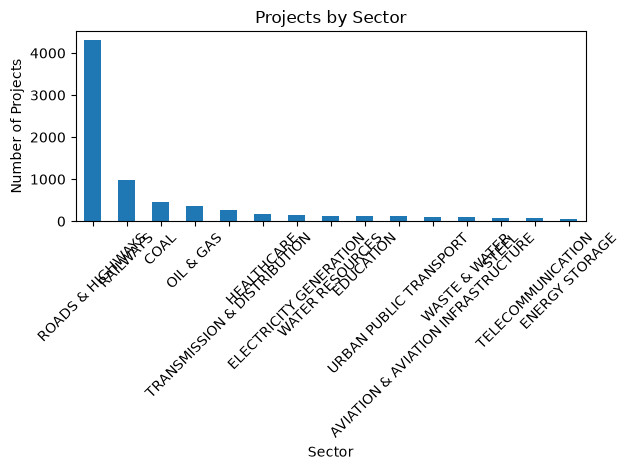

In [3]:
df["SECTOR"].value_counts().head(15).plot(    kind="bar" ) 
plt.title("Projects by Sector") 
plt.xlabel("Sector") 
plt.ylabel("Number of Projects") 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

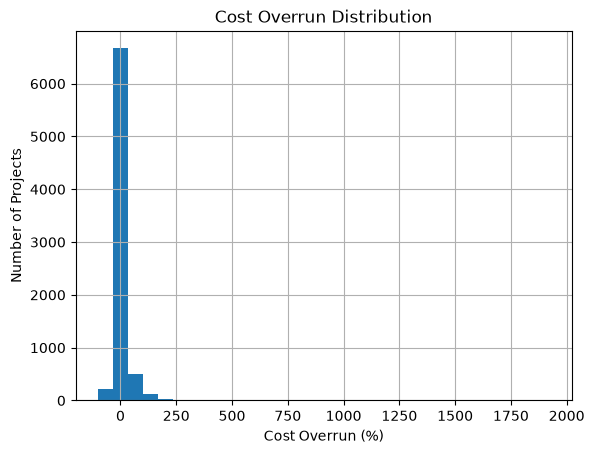

In [26]:
# Analysis 2 — Cost overrun distribution

df["COST_OVERRUN_PCT"].hist(bins=30) 
plt.title("Cost Overrun Distribution") 
plt.xlabel("Cost Overrun (%)") 
plt.ylabel("Number of Projects") 
plt.show()

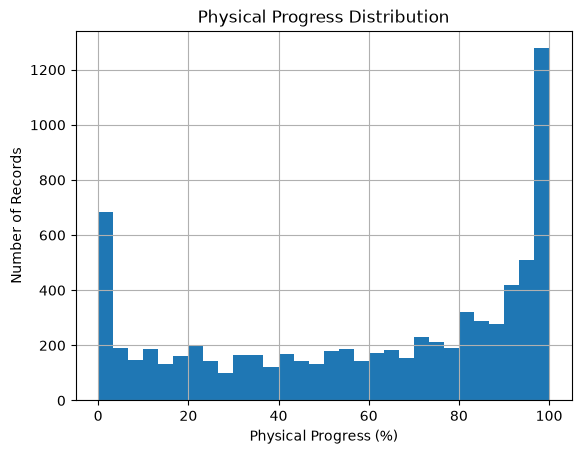

In [13]:
# Analysis 3 — Physical progress

df["PHYSICAL_PROGRESS_PERCENT"].hist(    bins=30 ) 
plt.title("Physical Progress Distribution") 
plt.xlabel("Physical Progress (%)") 
plt.ylabel("Number of Records") 
plt.show()

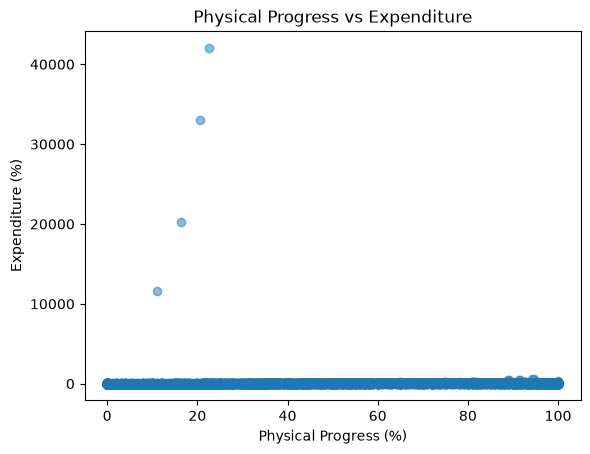

In [18]:
# Analysis 4 — Expenditure vs physical progress

plt.scatter(df["PHYSICAL_PROGRESS_PERCENT"], expenditure_pct, alpha=0.5)
plt.xlabel("Physical Progress (%)") 
plt.ylabel("Expenditure (%)") 
plt.title(    "Physical Progress vs Expenditure" ) 
plt.show()

In [36]:
df["PROGRESS_GAP"] = expenditure_pct - df["PHYSICAL_PROGRESS_PERCENT"]
high_gap = df[df["PROGRESS_GAP"] > 20].copy()
print(    "Records with expenditure more than 20 percentage points above physical progress:",    
len(high_gap) )

Records with expenditure more than 20 percentage points above physical progress: 465


In [23]:
high_gap[    [        
    "PROJECT_CODES",        
    "PROJECT_NAME",        
    "SECTOR",        
    "PROGRESS_GAP"    
    ] 
].head(20)

,PROJECT_CODES,PROJECT_NAME,SECTOR,PROGRESS_GAP
14,400006 | - | -,JHARSUGUDA-BARPALI-SARDEGA PH II WORKS- RAIL C...,RAILWAYS,51.899776
15,400006 | - | -,JHARSUGUDA-BARPALI-SARDEGA PH II WORKS- RAIL C...,RAILWAYS,47.899776
16,400006 | - | 4689,JHARSUGUDA-BARPALI-SARDEGA PH II WORKS- RAIL C...,RAILWAYS,48.669798
17,400006 | - | 4689,JHARSUGUDA-BARPALI-SARDEGA PH II WORKS- RAIL C...,RAILWAYS,51.899776
36,400019 | N22000514 | 4514,DHULE [BORVIHIR] - NARDANA NEW LINE [50.60 KMS],RAILWAYS,21.314153
37,400022 | - | -,TARANGA HILL-ABU ROAD VIA AMBAJI,RAILWAYS,48.513581
39,400022 | N22000592 | 4458,TARANGA HILL-ABU ROAD VIA AMBAJI,RAILWAYS,50.180843
40,400022 | N22000592 | 4458,TARANGA HILL-ABU ROAD VIA AMBAJI,RAILWAYS,54.827019
111,400107 | - | 3330,SULWADE-JAMPHAL-KANOLI LIFT IRRIGATION SCHEME,WATER RESOURCES,34.898578
117,400112 | - | 3314,JIGAON IRRIGATION PROJECT,WATER RESOURCES,53.600205


In [31]:
df["SCHEDULE_CHANGE_DAYS"] = (pd.to_datetime(df["REVISED_DOC"]) - pd.to_datetime(df["ORIGINAL_TARGET_DOC"])).dt.days
delayed = df[df["SCHEDULE_CHANGE_DAYS"] > 0].copy()
print("Records with positive schedule change:",    len(delayed) )

Records with positive schedule change: 4793


C:\Users\commu\AppData\Local\Temp\ipykernel_14776\1328915662.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["SCHEDULE_CHANGE_DAYS"] = (pd.to_datetime(df["REVISED_DOC"]) - pd.to_datetime(df["ORIGINAL_TARGET_DOC"])).dt.days
C:\Users\commu\AppData\Local\Temp\ipykernel_14776\1328915662.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["SCHEDULE_CHANGE_DAYS"] = (pd.to_datetime(df["REVISED_DOC"]) - pd.to_datetime(df["ORIGINAL_TARGET_DOC"])).dt.days


In [28]:
monthly_progress = (    df.groupby("REPORT_MONTH")[        
    "PHYSICAL_PROGRESS_PERCENT"    ]    
    .mean() ) 
monthly_progress

REPORT_MONTH
APRIL    60.209621
JULY     58.996625
JUNE     58.846649
MAY      60.225551
Name: PHYSICAL_PROGRESS_PERCENT, dtype: float64

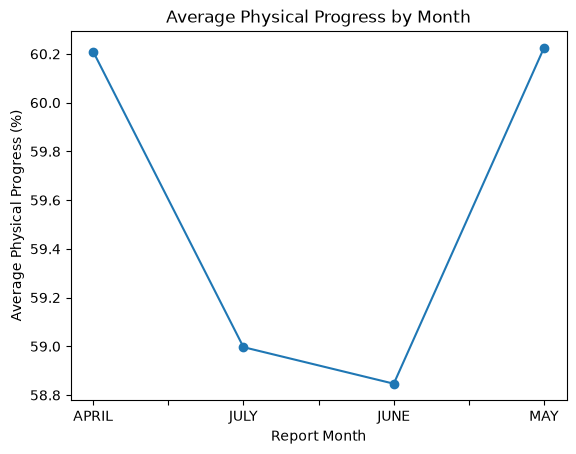

In [29]:
monthly_progress.plot(    marker="o" ) 
plt.title(    "Average Physical Progress by Month" ) 
plt.xlabel("Report Month") 
plt.ylabel("Average Physical Progress (%)") 
plt.show()

In [32]:
quality_report = pd.DataFrame({    
    "Column": df.columns,    
    "Data_Type": [        
        str(df[col].dtype)        
        for col in df.columns    ],    
    "Missing_Count": [        
        df[col].isna().sum()        
        for col in df.columns    ],    
    "Missing_Percentage": [        
        round(df[col].isna().mean() * 100, 2)        
        for col in df.columns    ],    
    "Unique_Values": [        
        df[col].nunique()        
        for col in df.columns    ] }) 
quality_report.to_excel(    "../reports/data_quality_report.xlsx",    index=False ) 
print("Data quality report created")

Data quality report created


In [33]:
data_dictionary = pd.DataFrame({    
    "Column": df.columns,    
    "Meaning": "",    
    "Data_Type": [        
        str(df[col].dtype)        
        for col in df.columns    ],    
    "Missing_Count": [df[col].isna().sum() for col in df.columns ] }) 
data_dictionary.to_excel( "../reports/data_dictionary.xlsx", index=False ) 
print("Data dictionary created")

Data dictionary created
